In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [17]:
df = pd.read_csv("../Data/raw/healthcare_dataset.csv")

In [18]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [19]:
df.shape

(55500, 15)

In [20]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 12.3 MB


In [22]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [23]:
df.isnull().sum().sum()

np.int64(0)

In [24]:
df.duplicated().sum()

np.int64(534)

In [25]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [26]:
df['Gender'].value_counts()

Gender
Male      27774
Female    27726
Name: count, dtype: int64

In [27]:
df['Medical Condition'].value_counts()

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

In [28]:
df['Admission Type'].value_counts()

Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

In [29]:
df['Insurance Provider'].value_counts()

Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

In [30]:
df['Medication'].value_counts()

Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

In [31]:
df['Test Results'].value_counts()

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

In [32]:
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission']
)

In [33]:
df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date']
)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  str           
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  str           
 3   Blood Type          55500 non-null  str           
 4   Medical Condition   55500 non-null  str           
 5   Date of Admission   55500 non-null  datetime64[us]
 6   Doctor              55500 non-null  str           
 7   Hospital            55500 non-null  str           
 8   Insurance Provider  55500 non-null  str           
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  str           
 12  Discharge Date      55500 non-null  datetime64[us]
 13  Medication          55500 non-null  str           
 14  T

In [35]:
df['Length of Stay'] = (
    df['Discharge Date'] -
    df['Date of Admission']
).dt.days

In [36]:
df['Length of Stay'].describe()

count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64

In [37]:
bins = [0, 18, 30, 45, 60, 75, 100]

labels = [
    '0-18',
    '19-30',
    '31-45',
    '46-60',
    '61-75',
    '76+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [38]:
df['Age Group'].value_counts().sort_index()

Age Group
0-18       888
19-30     9611
31-45    12230
46-60    12401
61-75    12216
76+       8154
Name: count, dtype: int64

In [39]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Male      27774
Female    27726
Name: count, dtype: int64

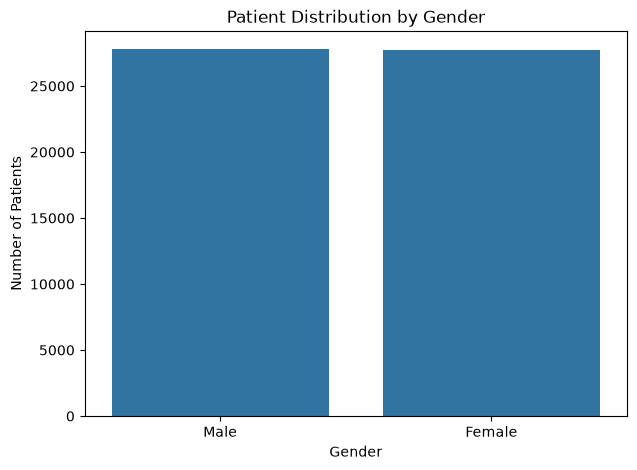

In [85]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title('Patient Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

plt.show()

### Interpretation

The count plot shows the distribution of patients across different gender categories. The height of each bar represents the number of patients in that category.

The chart helps us understand the gender composition of the healthcare dataset. The category with the highest bar represents the largest patient group, while the category with the lowest bar represents the smallest patient group.

This analysis provides an overview of patient demographics and can be used as a basis for further analysis of medical conditions, billing, admission types, and other healthcare variables by gender.

In [87]:
import os

visualization_path = "../Visualizations"
os.makedirs(visualization_path, exist_ok=True)

print("Visualizations folder created successfully!")

Visualizations folder created successfully!


In [88]:
plt.savefig(
    "../Visualizations/patient_distribution_gender.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [41]:
condition_counts = (
    df['Medical Condition']
    .value_counts()
)

condition_counts

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

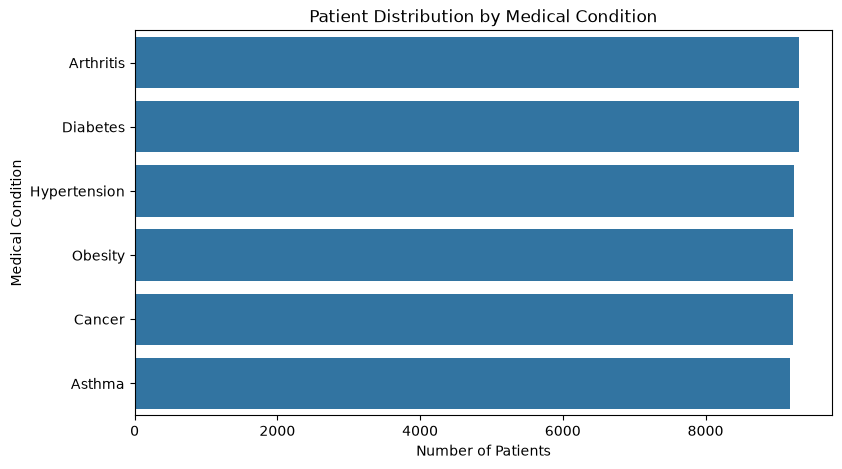

In [42]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    y='Medical Condition',
    order=condition_counts.index
)

plt.title('Patient Distribution by Medical Condition')
plt.xlabel('Number of Patients')
plt.ylabel('Medical Condition')

plt.show()

### Interpretation

The count plot shows the distribution of patients across different medical conditions. The length of each bar represents the number of patients associated with that medical condition.

The chart allows us to compare the prevalence of different medical conditions within the dataset. The medical condition with the longest bar represents the largest patient group, while the shortest bar represents the smallest patient group.

This analysis helps identify the most frequently recorded medical conditions and provides a foundation for further analysis of billing amounts, admission types, length of stay, and test results across different medical conditions.

In [43]:
age_group_counts = (
    df['Age Group']
    .value_counts()
    .sort_index()
)

age_group_counts

Age Group
0-18       888
19-30     9611
31-45    12230
46-60    12401
61-75    12216
76+       8154
Name: count, dtype: int64

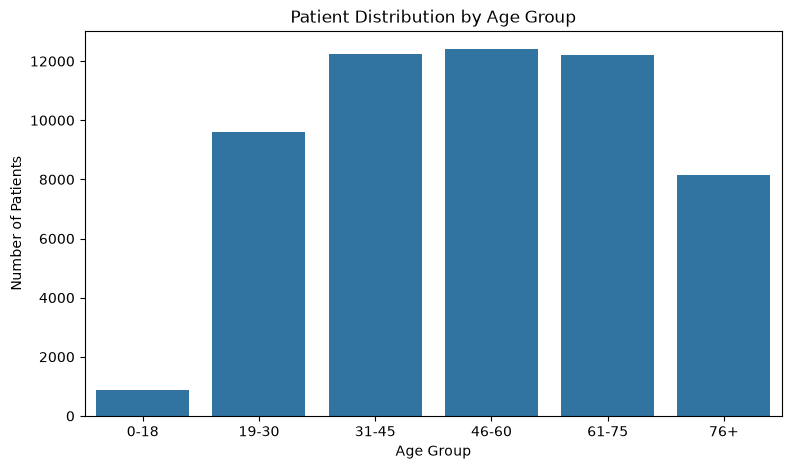

In [44]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Age Group'
)

plt.title('Patient Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')

plt.show()

### Interpretation

The count plot shows the distribution of patients across different age groups. The height of each bar represents the number of patients belonging to that age group.

The visualization helps identify which age groups have the highest and lowest number of patients in the dataset. This provides an overview of the age composition of the patient population.

Age-group analysis can be useful for further exploring patterns in medical conditions, billing amounts, admission types, length of stay, and other healthcare variables.

In [45]:
condition_billing = (
    df.groupby('Medical Condition')['Billing Amount']
    .mean()
    .sort_values(ascending=False)
)

condition_billing

Medical Condition
Obesity         25805.971259
Diabetes        25638.405577
Asthma          25635.249359
Arthritis       25497.327056
Hypertension    25497.095761
Cancer          25161.792707
Name: Billing Amount, dtype: float64

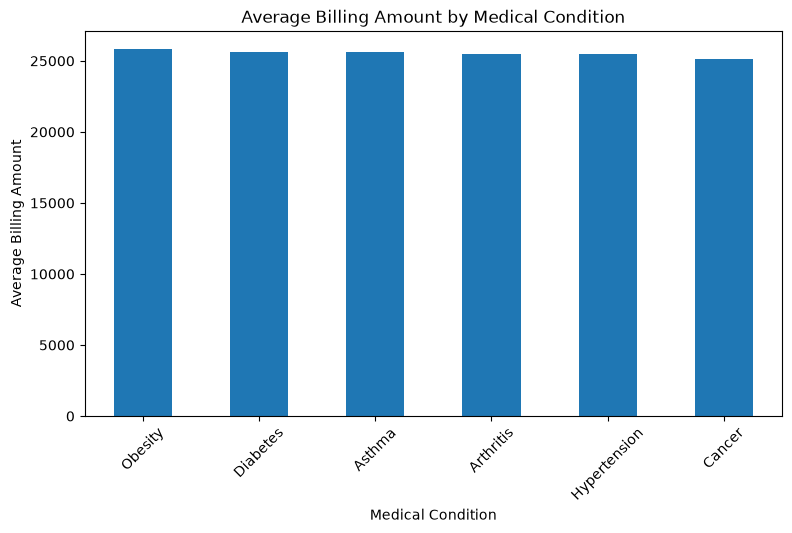

In [46]:
plt.figure(figsize=(9,5))

condition_billing.plot(kind='bar')

plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')

plt.xticks(rotation=45)

plt.show()

### Interpretation

The bar chart compares the average billing amount across different medical conditions.

The results show that the average billing amount varies between medical conditions. The medical condition with the tallest bar has the highest average billing amount, while the condition with the shortest bar has the lowest average billing amount.

This analysis helps identify differences in average healthcare costs across medical conditions. It can also be used as a starting point for further investigation into factors such as length of stay, admission type, and other variables that may be associated with billing differences.

Since this is a synthetic healthcare dataset, these findings should be interpreted as patterns within the dataset and not as real-world medical or healthcare cost conclusions.

In [47]:
hospital_counts = (
    df['Hospital']
    .value_counts()
    .head(10)
)

hospital_counts

Hospital
LLC Smith      44
Ltd Smith      39
Johnson PLC    38
Smith Ltd      37
Smith PLC      36
Smith Group    36
Johnson Inc    35
Smith Inc      34
Smith LLC      32
Group Smith    32
Name: count, dtype: int64

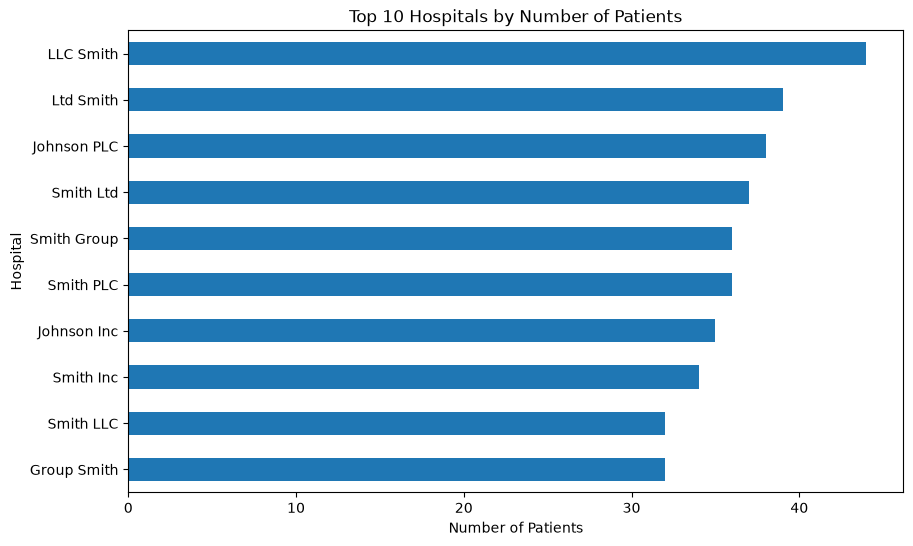

In [48]:
plt.figure(figsize=(10,6))

hospital_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Hospitals by Number of Patients')
plt.xlabel('Number of Patients')
plt.ylabel('Hospital')

plt.show()

### Interpretation

The bar chart shows the top 10 hospitals with the highest number of patient records in the dataset.

The length of each bar represents the number of patients associated with each hospital. The hospital with the longest bar has the highest patient count among the top 10 hospitals, while the shortest bar has the lowest patient count within this group.

This analysis helps identify hospitals with relatively higher patient volumes in the dataset. Patient volume can be useful for understanding hospital activity and comparing the distribution of patient records across different hospitals.

Since this dataset is synthetic, the results represent patterns within the dataset and should not be interpreted as actual hospital performance or real-world patient volumes.

In [49]:
insurance_counts = (
    df['Insurance Provider']
    .value_counts()
)

insurance_counts

Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

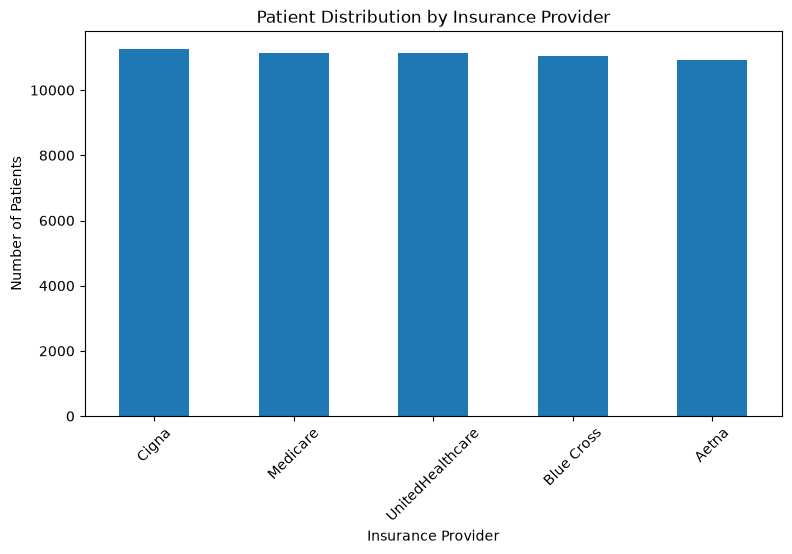

In [50]:
plt.figure(figsize=(9,5))

insurance_counts.plot(kind='bar')

plt.title('Patient Distribution by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45)

plt.show()

### Interpretation

The bar chart shows the distribution of patients across different insurance providers.

The height of each bar represents the number of patient records associated with each insurance provider. The provider with the tallest bar has the highest number of patients, while the provider with the shortest bar has the lowest number of patients.

This analysis helps understand the distribution of patients among different insurance providers and provides a basis for further analysis of billing amounts and healthcare costs by insurance provider.

Since this dataset is synthetic, the results represent patterns within the dataset and should not be interpreted as actual market share or performance of real insurance companies.

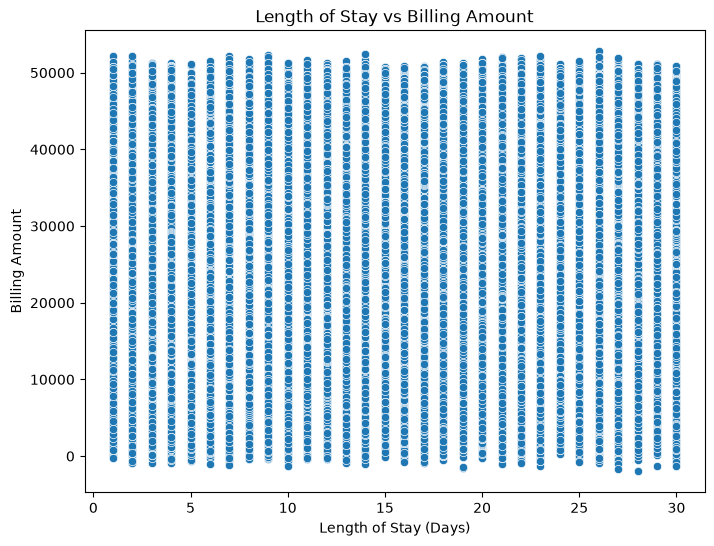

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Length of Stay',
    y='Billing Amount'
)

plt.title('Length of Stay vs Billing Amount')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Billing Amount')

plt.show()

### Interpretation

The scatter plot shows the relationship between the length of a patient's hospital stay and their billing amount.

The distribution of points helps us observe whether billing amounts tend to increase or decrease as the length of stay changes. A clear upward pattern would indicate a positive relationship, while a scattered pattern would indicate a weak relationship.

This analysis helps identify whether longer hospital stays are associated with higher billing amounts in the dataset. However, the scatter plot alone does not establish causation, and other factors may also influence billing amounts.

In [52]:
df[
    ['Length of Stay', 'Billing Amount']
].corr()

,Length of Stay,Billing Amount
Length of Stay,1.000000,-0.005602
Billing Amount,-0.005602,1.000000


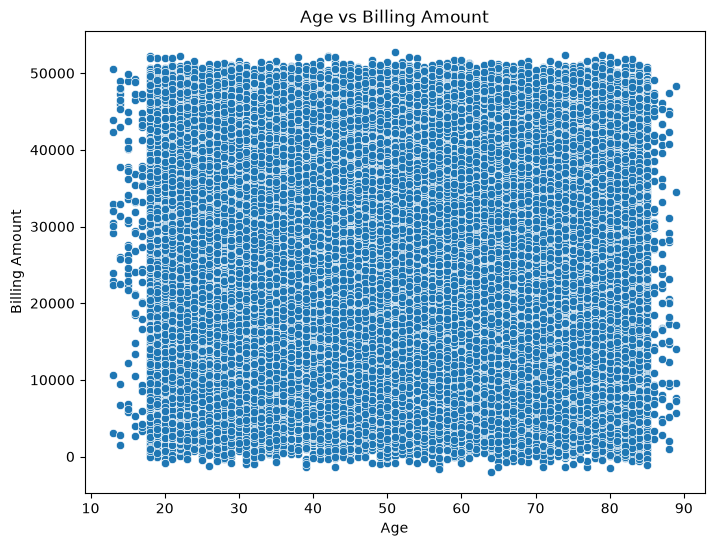

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Billing Amount'
)

plt.title('Age vs Billing Amount')
plt.xlabel('Age')
plt.ylabel('Billing Amount')

plt.show()

### Interpretation

The scatter plot shows the relationship between patient age and billing amount.

The distribution of points helps us observe how billing amounts vary across different ages. If the points show a clear upward pattern, it suggests that billing amount tends to increase with age. If the points are widely scattered, it indicates a weak relationship between age and billing amount.

This analysis helps determine whether patient age is associated with differences in billing amounts within the dataset. However, the scatter plot alone cannot establish a causal relationship, and other factors may contribute to variations in billing amounts.

In [54]:
df[['Age', 'Billing Amount']].corr()

,Age,Billing Amount
Age,1.000000,-0.003832
Billing Amount,-0.003832,1.000000


In [55]:
admission_billing = (
    df.groupby('Admission Type')['Billing Amount']
    .mean()
    .sort_values(ascending=False)
)

admission_billing

Admission Type
Elective     25602.226311
Urgent       25517.364497
Emergency    25497.397157
Name: Billing Amount, dtype: float64

In [56]:
admission_billing = (
    df.groupby('Admission Type')['Billing Amount']
    .mean()
    .sort_values(ascending=False)
)

admission_billing

Admission Type
Elective     25602.226311
Urgent       25517.364497
Emergency    25497.397157
Name: Billing Amount, dtype: float64

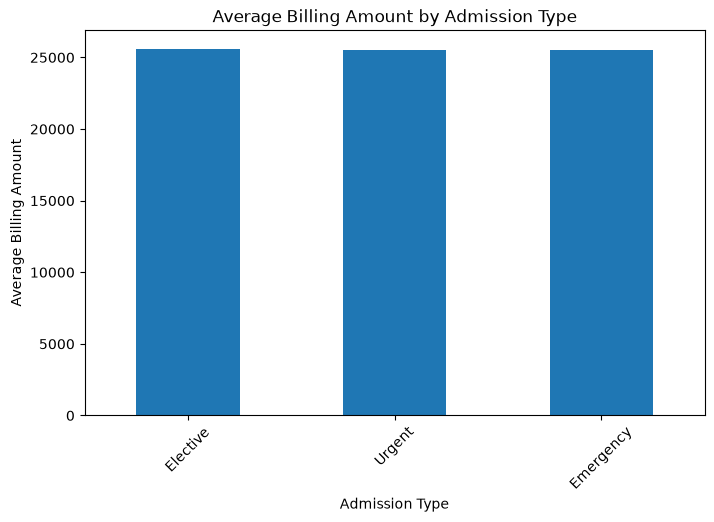

In [57]:
plt.figure(figsize=(8,5))

admission_billing.plot(kind='bar')

plt.title('Average Billing Amount by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Average Billing Amount')

plt.xticks(rotation=45)

plt.show()

### Interpretation

The bar chart compares the average billing amount across different admission types.

The results show that the average billing amount varies between admission categories. The admission type with the tallest bar has the highest average billing amount, while the shortest bar represents the lowest average billing amount.

This analysis helps identify differences in billing patterns across admission types and provides a better understanding of how average billing varies based on the type of hospital admission.

Since this is a synthetic healthcare dataset, these results represent patterns within the dataset and should not be interpreted as actual healthcare cost differences in real-world hospitals.

In [58]:
pd.crosstab(
    df['Medical Condition'],
    df['Test Results']
)

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,3188,3088,3032
Asthma,3009,3029,3147
Cancer,3118,3060,3049
Diabetes,3168,3046,3090
Hypertension,3012,3091,3142
Obesity,3132,3042,3057


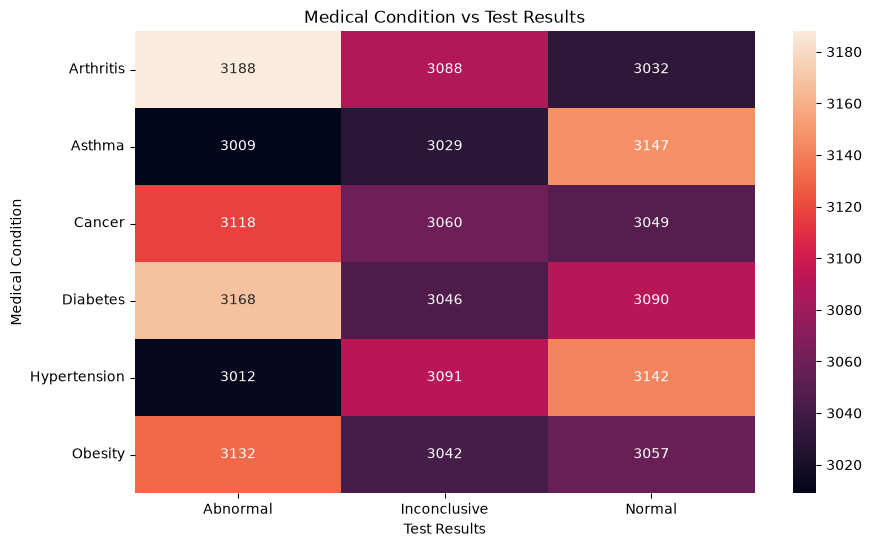

In [59]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pd.crosstab(
        df['Medical Condition'],
        df['Test Results']
    ),
    annot=True,
    fmt='d'
)

plt.title('Medical Condition vs Test Results')

plt.show()

### Interpretation

The heatmap shows the distribution of test results across different medical conditions. Each cell represents the number of patients belonging to a particular combination of medical condition and test result.

The darker or higher-valued cells indicate combinations with a larger number of patients, while lower values indicate fewer patients.

This analysis helps identify how test-result categories are distributed across different medical conditions. It can be useful for understanding patterns in the dataset and for comparing the distribution of test results between medical-condition groups.

Since this is a synthetic healthcare dataset, the observed patterns should be interpreted only as relationships within the dataset and should not be considered medical or clinical conclusions.

In [60]:
df['Year'] = (
    df['Date of Admission']
    .dt.year
)

df['Month'] = (
    df['Date of Admission']
    .dt.month
)

df['Month Name'] = (
    df['Date of Admission']
    .dt.month_name()
)

In [61]:
yearly_admissions = (
    df.groupby('Year')
    .size()
)

yearly_admissions

Year
2019     7387
2020    11285
2021    10931
2022    11017
2023    11026
2024     3854
dtype: int64

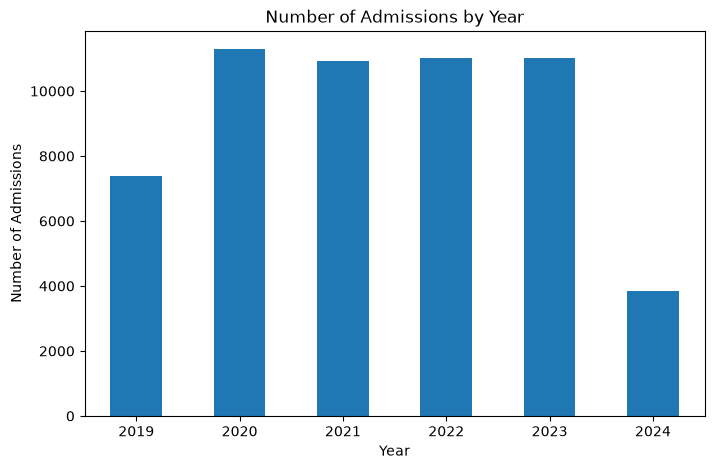

In [62]:
plt.figure(figsize=(8,5))

yearly_admissions.plot(kind='bar')

plt.title('Number of Admissions by Year')
plt.xlabel('Year')
plt.ylabel('Number of Admissions')

plt.xticks(rotation=0)

plt.show()

### Interpretation

The bar chart shows the number of patient admissions recorded for each year in the dataset.

The chart allows us to compare admission volumes across different years and identify whether the number of admissions increased or decreased over time.

The year with the highest bar represents the year with the largest number of recorded admissions, while the year with the lowest bar represents the smallest admission volume.

This analysis provides an overview of the yearly distribution of patient admissions and helps identify changes in admission volume over the period covered by the dataset.

In [63]:
monthly_admissions = (
    df.groupby('Month')
    .size()
)

monthly_admissions

Month
1     4692
2     4255
3     4672
4     4518
5     4599
6     4699
7     4812
8     4832
9     4546
10    4678
11    4548
12    4649
dtype: int64

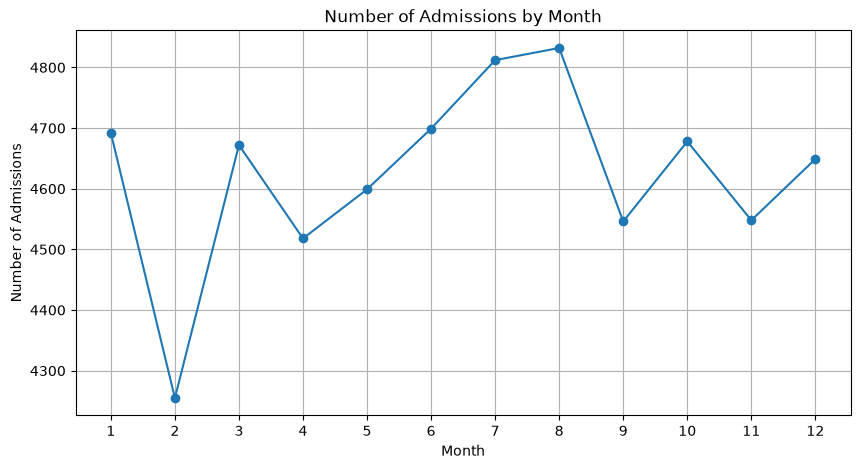

In [64]:
plt.figure(figsize=(10,5))

monthly_admissions.sort_index().plot(
    kind='line',
    marker='o'
)

plt.title('Number of Admissions by Month')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')

plt.xticks(range(1, 13))

plt.grid(True)

plt.show()

### Interpretation

The line chart shows the distribution of patient admissions across the months of the year.

The monthly trend helps identify which months have relatively higher or lower admission volumes. Peaks in the line represent months with higher numbers of recorded admissions, while lower points represent months with fewer admissions.

This analysis helps identify seasonal patterns or variations in patient admission volume within the dataset. The observed pattern can be useful for understanding how admissions are distributed throughout the year.

In [65]:
Q1 = df['Billing Amount'].quantile(0.25)
Q3 = df['Billing Amount'].quantile(0.75)

IQR = Q3 - Q1

In [66]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [67]:
outliers = df[
    (df['Billing Amount'] < lower_bound) |
    (df['Billing Amount'] > upper_bound)
]

len(outliers)

0

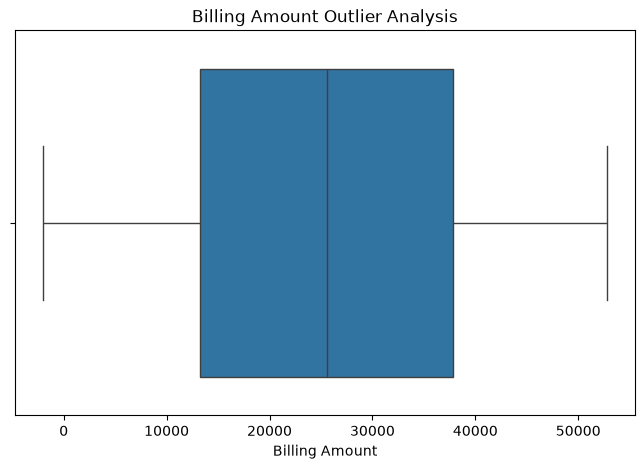

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Billing Amount']
)

plt.title('Billing Amount Outlier Analysis')

plt.show()

### Interpretation

The box plot shows the distribution of billing amounts and helps identify unusually high or low billing values in the dataset.

The box represents the middle 50% of billing amounts, while the line inside the box represents the median. The whiskers show the typical range of billing amounts, and the individual points beyond the whiskers represent potential outliers.

The visualization shows several high-value billing observations beyond the upper whisker. These values are considerably higher than the majority of billing amounts and should be investigated further rather than automatically removed.

Outliers may represent legitimate high-cost patient records or unusual observations in the dataset. Therefore, they should be evaluated based on the business context before deciding whether to retain or remove them.

In [69]:
numeric_cols = [
    'Age',
    'Billing Amount',
    'Room Number',
    'Length of Stay'
]

In [70]:
correlation = df[numeric_cols].corr()

correlation

,Age,Billing Amount,Room Number,Length of Stay
Age,1.000000,-0.003832,-0.000720,0.008220
Billing Amount,-0.003832,1.000000,-0.002943,-0.005602
Room Number,-0.000720,-0.002943,1.000000,-0.005526
Length of Stay,0.008220,-0.005602,-0.005526,1.000000


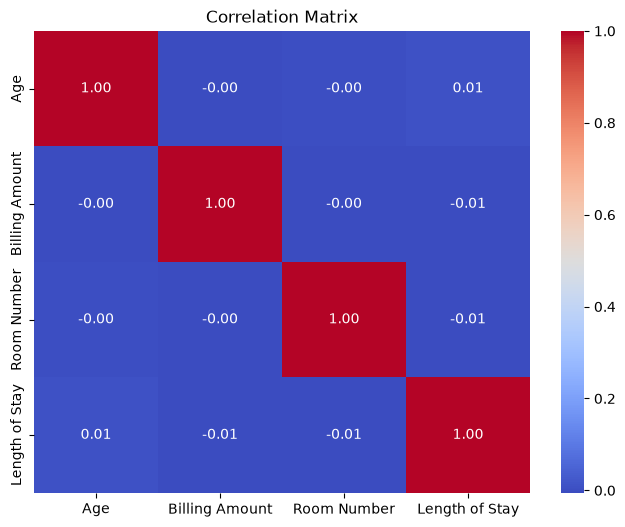

In [71]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

### Interpretation

The correlation heatmap shows the strength and direction of the linear relationships between the numerical variables in the dataset.

The correlation values range from **-1 to +1**. Values closer to **+1** indicate a strong positive relationship, values closer to **-1** indicate a strong negative relationship, and values close to **0** indicate a weak or negligible linear relationship.

The heatmap makes it easier to identify which numerical variables have stronger relationships with each other. In particular, the relationship between **Length of Stay** and **Billing Amount** can be examined to determine whether longer hospital stays are associated with higher billing amounts.

Correlation indicates association between variables and does not imply that one variable causes changes in another.

In [72]:
total_patients = len(df)
total_patients

55500

In [73]:
average_age = df['Age'].mean()
average_age

np.float64(51.53945945945946)

In [74]:
average_billing = df['Billing Amount'].mean()
average_billing

np.float64(25539.316097211795)

In [75]:
average_stay = df['Length of Stay'].mean()
average_stay

np.float64(15.50900900900901)

In [76]:
most_common_condition = df['Medical Condition'].value_counts().idxmax()
most_common_condition

'Arthritis'

In [77]:
most_common_admission = df['Admission Type'].value_counts().idxmax()
most_common_admission

'Elective'

In [78]:
most_common_insurance = df['Insurance Provider'].value_counts().idxmax()
most_common_insurance

'Cigna'

## Key Business Insights

Based on the exploratory data analysis, the following key insights were identified:

1. **Patient Demographics:** The dataset contains patients across different age groups and gender categories, providing an overview of the demographic composition of the patient population.

2. **Medical Conditions:** The distribution of medical conditions shows that some conditions have a higher number of recorded patients than others.

3. **Hospital Patient Volume:** The analysis of hospitals identified the hospitals with the highest number of patient records, providing an overview of patient volume across hospitals.

4. **Insurance Distribution:** Patient records are distributed across multiple insurance providers, with some providers having a larger share of the dataset.

5. **Billing Analysis:** Average billing amounts vary across medical conditions and admission types, indicating differences in billing patterns within the dataset.

6. **Length of Stay:** The length-of-stay analysis provides insight into how long patients remained hospitalized and allows comparison with billing amounts.

7. **Time Analysis:** Yearly and monthly admission analysis shows how patient admissions are distributed over time and helps identify periods with relatively higher or lower admission volumes.

8. **Outlier Analysis:** The billing analysis identified unusually high billing observations. These observations should be investigated rather than automatically removed because they may represent legitimate high-value records.

9. **Correlation Analysis:** The correlation matrix helps identify the strength and direction of relationships between numerical variables such as age, billing amount, room number, and length of stay.

10. **Healthcare Data Patterns:** Overall, the analysis demonstrates how patient demographics, admission characteristics, billing, hospital activity, and other variables can be explored using Pandas and visualization techniques.

## Business Recommendations

Based on the patterns identified during the exploratory analysis, the following recommendations can be considered:

1. **Monitor Patient Volume:** Hospitals with higher patient volumes can be monitored for resource planning and operational capacity.

2. **Analyze Billing Variation:** Differences in average billing across medical conditions and admission types should be investigated to understand the factors contributing to billing variation.

3. **Monitor Length of Stay:** Length-of-stay patterns can be analyzed alongside billing amounts to identify operational patterns that may require further investigation.

4. **Review High-Value Billing Records:** Potential billing outliers should be reviewed individually rather than automatically removed from the dataset.

5. **Monitor Admission Trends:** Monthly and yearly admission patterns can support capacity planning and resource allocation.

6. **Use Data-Driven Analysis:** Regular analysis of patient, admission, billing, and insurance data can help organizations identify operational patterns and areas requiring further investigation.

These recommendations are based on patterns within the provided synthetic dataset and should not be interpreted as clinical recommendations.

## Conclusion

This project analyzed a healthcare dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The analysis covered data understanding, data quality assessment, data cleaning, feature engineering, descriptive statistics, patient demographics, medical conditions, hospital activity, insurance providers, admission types, billing amounts, time-based admission patterns, bivariate analysis, outlier detection, and correlation analysis.

The exploratory analysis helped identify patterns and relationships within the dataset and demonstrated how Pandas can be used to transform raw healthcare data into meaningful analytical insights.

The project also highlighted the importance of investigating missing values, duplicate records, outliers, data types, and relationships between variables before drawing conclusions from a dataset.

Overall, this project demonstrates an end-to-end exploratory data analysis workflow and provides practical experience in using Python and Pandas for data cleaning, analysis, visualization, and insight generation.

In [79]:
df.to_csv(
    "../data/cleaned/healthcare_cleaned.csv",
    index=False
)

In [90]:
plt.savefig(
    "../Visualizations/age_group_distribution.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [89]:
plt.savefig(
    "../Visualizations/medical_condition_distribution.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

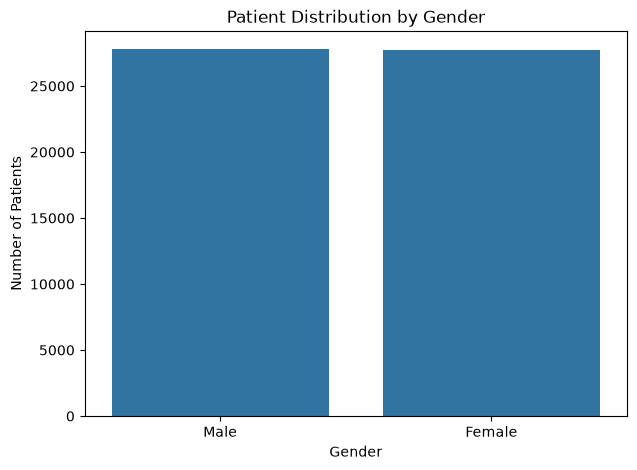

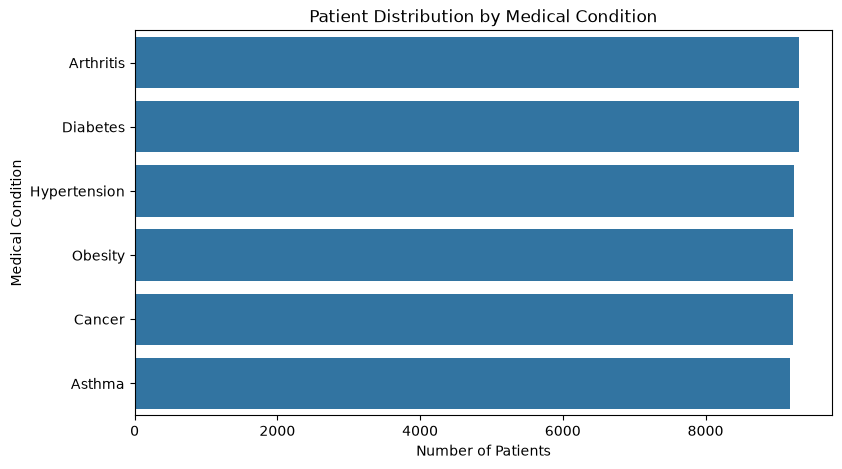

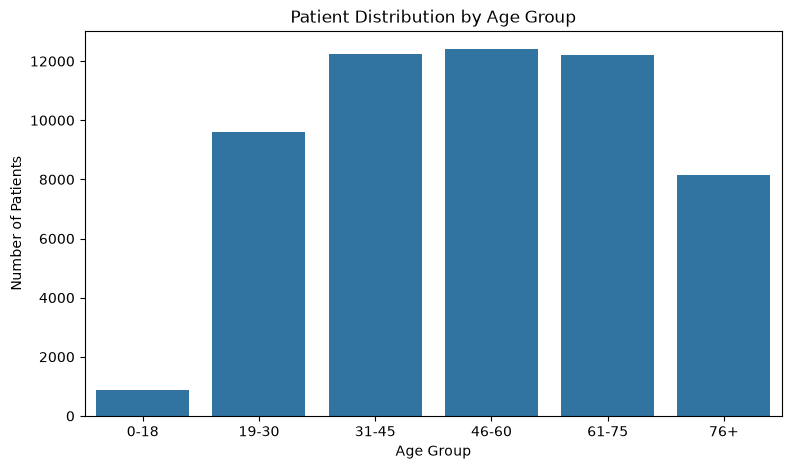

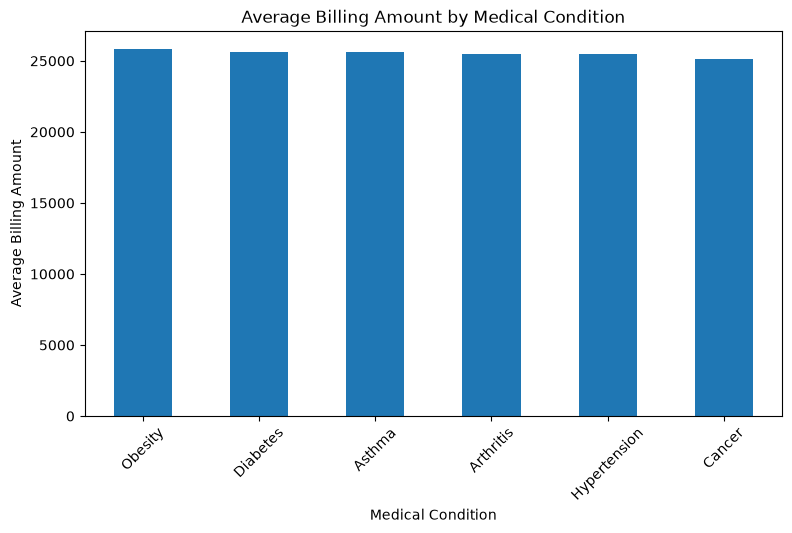

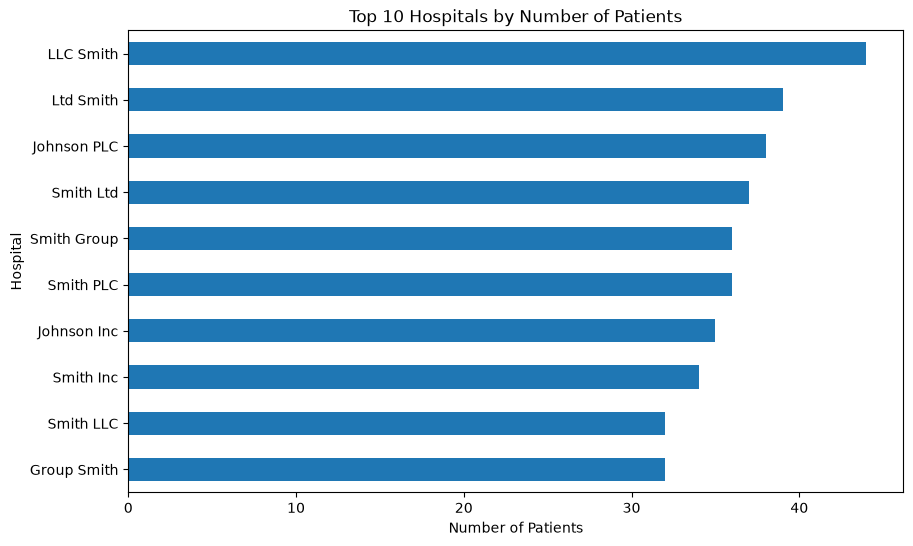

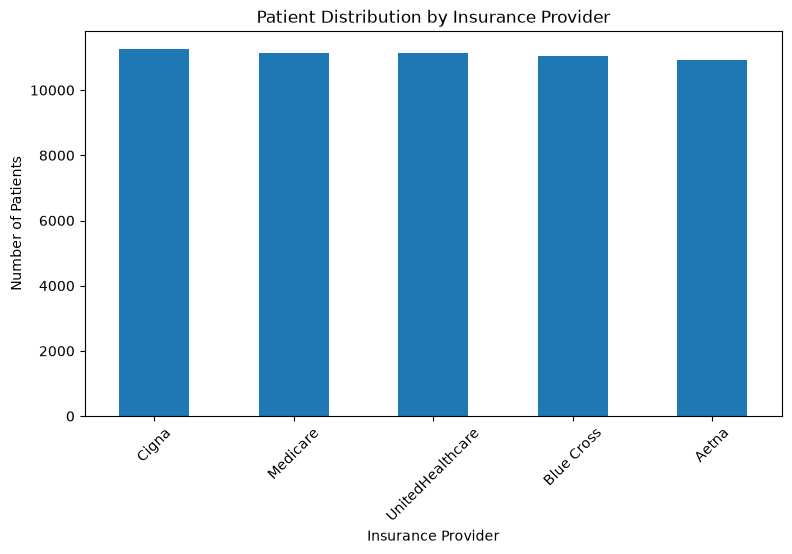

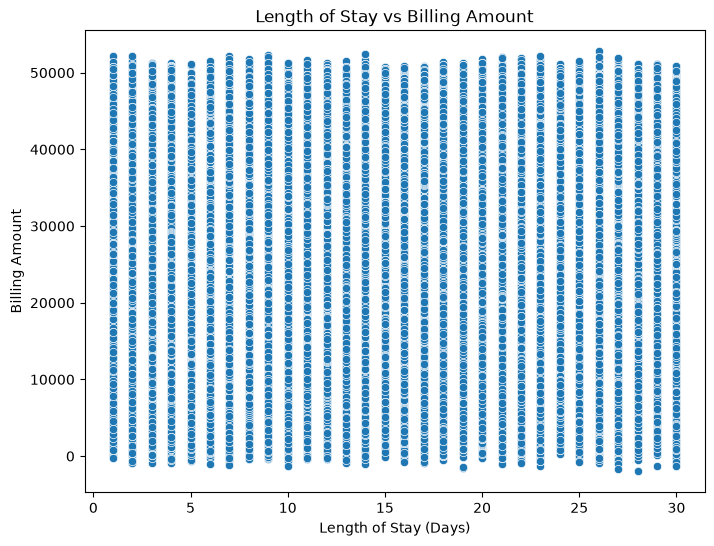

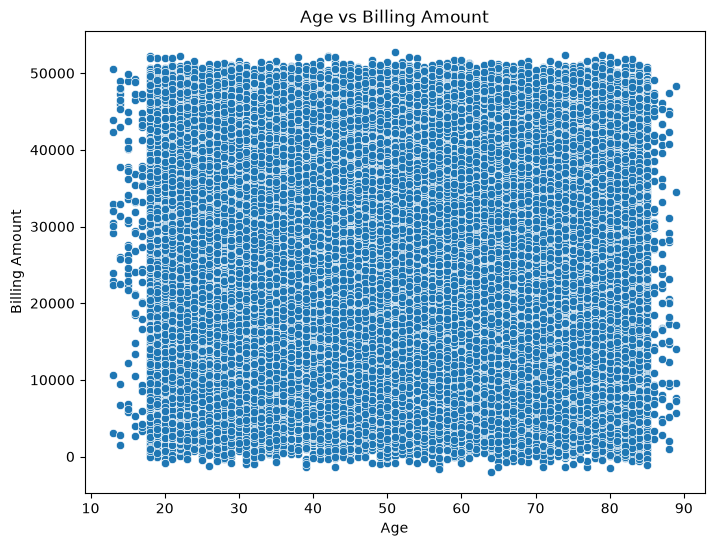

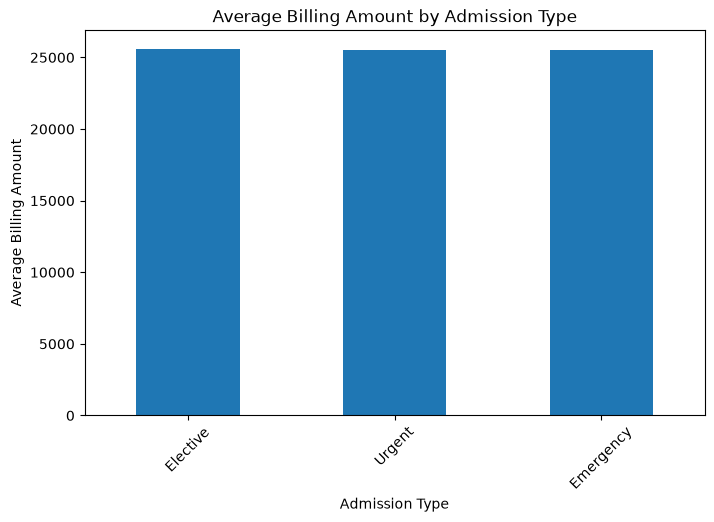

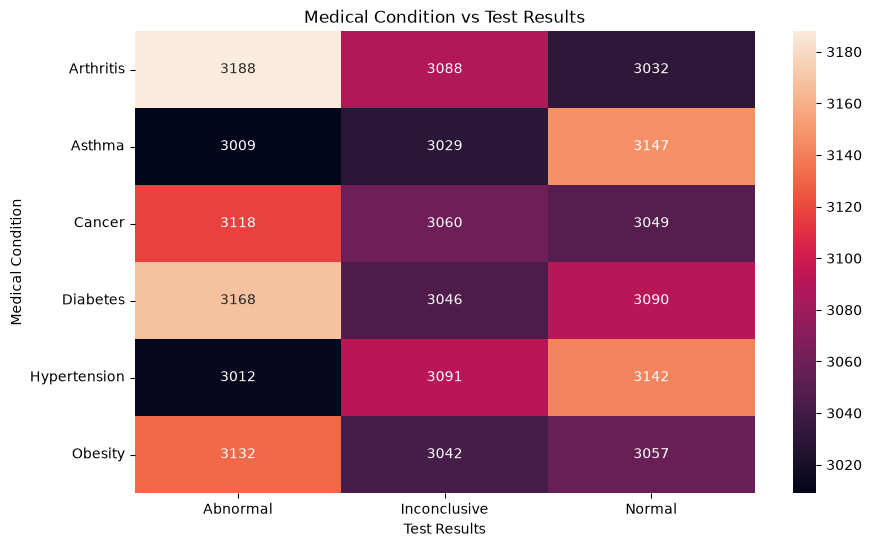

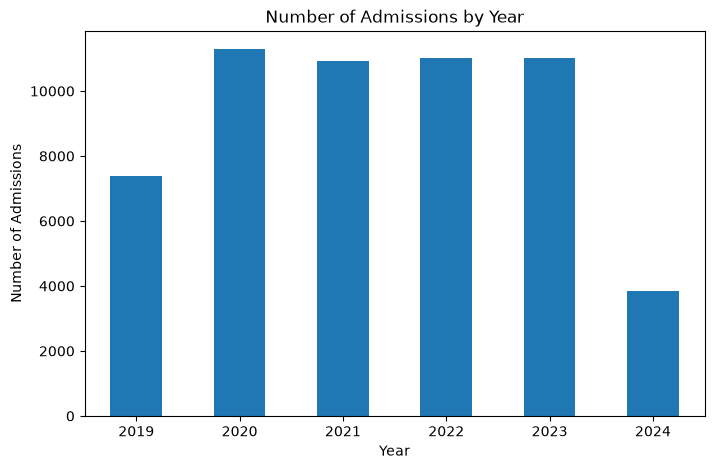

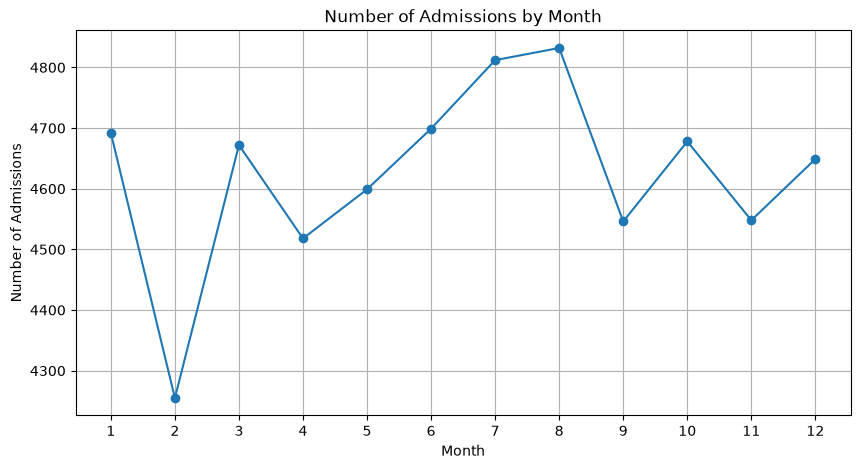

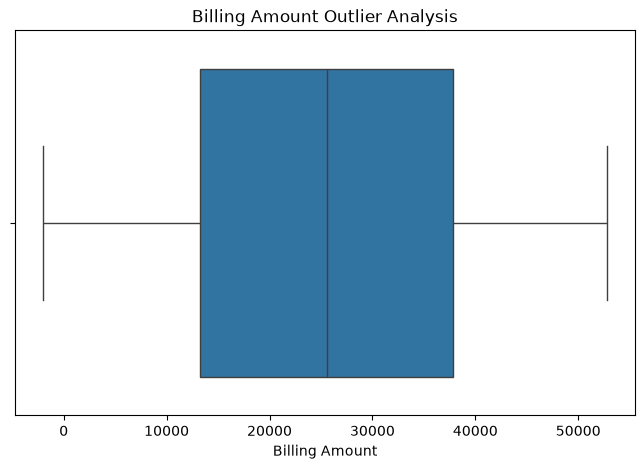

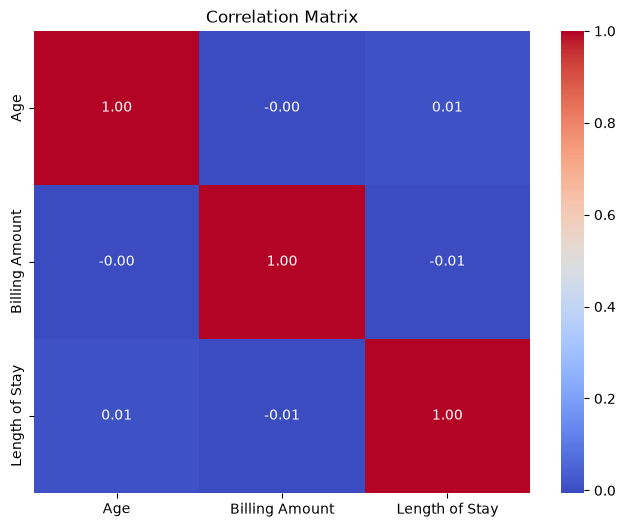

All visualizations saved successfully!


In [91]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create Visualizations folder
os.makedirs("../Visualizations", exist_ok=True)


# 1. Gender Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Gender')
plt.title('Patient Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.savefig("../Visualizations/patient_distribution_gender.png", bbox_inches='tight')
plt.show()
plt.close()


# 2. Medical Condition Distribution
condition_counts = df['Medical Condition'].value_counts()

plt.figure(figsize=(9, 5))
sns.countplot(data=df, y='Medical Condition', order=condition_counts.index)
plt.title('Patient Distribution by Medical Condition')
plt.xlabel('Number of Patients')
plt.ylabel('Medical Condition')
plt.savefig("../Visualizations/medical_condition_distribution.png", bbox_inches='tight')
plt.show()
plt.close()


# 3. Age Group Distribution
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Age Group')
plt.title('Patient Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.savefig("../Visualizations/age_group_distribution.png", bbox_inches='tight')
plt.show()
plt.close()


# 4. Average Billing by Medical Condition
condition_billing = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
condition_billing.plot(kind='bar')
plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.savefig("../Visualizations/billing_by_medical_condition.png", bbox_inches='tight')
plt.show()
plt.close()


# 5. Top 10 Hospitals
hospital_counts = df['Hospital'].value_counts().head(10)

plt.figure(figsize=(10, 6))
hospital_counts.sort_values().plot(kind='barh')
plt.title('Top 10 Hospitals by Number of Patients')
plt.xlabel('Number of Patients')
plt.ylabel('Hospital')
plt.savefig("../Visualizations/top_10_hospitals.png", bbox_inches='tight')
plt.show()
plt.close()


# 6. Insurance Provider Distribution
insurance_counts = df['Insurance Provider'].value_counts()

plt.figure(figsize=(9, 5))
insurance_counts.plot(kind='bar')
plt.title('Patient Distribution by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.savefig("../Visualizations/insurance_provider_distribution.png", bbox_inches='tight')
plt.show()
plt.close()


# 7. Length of Stay vs Billing Amount
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Length of Stay', y='Billing Amount')
plt.title('Length of Stay vs Billing Amount')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Billing Amount')
plt.savefig("../Visualizations/length_of_stay_vs_billing.png", bbox_inches='tight')
plt.show()
plt.close()


# 8. Age vs Billing Amount
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Billing Amount')
plt.title('Age vs Billing Amount')
plt.xlabel('Age')
plt.ylabel('Billing Amount')
plt.savefig("../Visualizations/age_vs_billing.png", bbox_inches='tight')
plt.show()
plt.close()


# 9. Average Billing by Admission Type
admission_billing = df.groupby('Admission Type')['Billing Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
admission_billing.plot(kind='bar')
plt.title('Average Billing Amount by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.savefig("../Visualizations/billing_by_admission_type.png", bbox_inches='tight')
plt.show()
plt.close()


# 10. Medical Condition vs Test Results
plt.figure(figsize=(10, 6))
sns.heatmap(
    pd.crosstab(df['Medical Condition'], df['Test Results']),
    annot=True,
    fmt='d'
)
plt.title('Medical Condition vs Test Results')
plt.savefig("../Visualizations/medical_condition_test_results.png", bbox_inches='tight')
plt.show()
plt.close()


# 11. Admissions by Year
df['Year'] = df['Date of Admission'].dt.year
yearly_admissions = df.groupby('Year').size()

plt.figure(figsize=(8, 5))
yearly_admissions.plot(kind='bar')
plt.title('Number of Admissions by Year')
plt.xlabel('Year')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=0)
plt.savefig("../Visualizations/admissions_by_year.png", bbox_inches='tight')
plt.show()
plt.close()


# 12. Admissions by Month
df['Month'] = df['Date of Admission'].dt.month
monthly_admissions = df.groupby('Month').size()

plt.figure(figsize=(10, 5))
monthly_admissions.sort_index().plot(kind='line', marker='o')
plt.title('Number of Admissions by Month')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.xticks(range(1, 13))
plt.grid(True)
plt.savefig("../Visualizations/admissions_by_month.png", bbox_inches='tight')
plt.show()
plt.close()


# 13. Billing Amount Outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Billing Amount'])
plt.title('Billing Amount Outlier Analysis')
plt.savefig("../Visualizations/billing_outliers.png", bbox_inches='tight')
plt.show()
plt.close()


# 14. Correlation Matrix
correlation = df[['Age', 'Billing Amount', 'Length of Stay']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig("../Visualizations/correlation_matrix.png", bbox_inches='tight')
plt.show()
plt.close()


print("All visualizations saved successfully!")